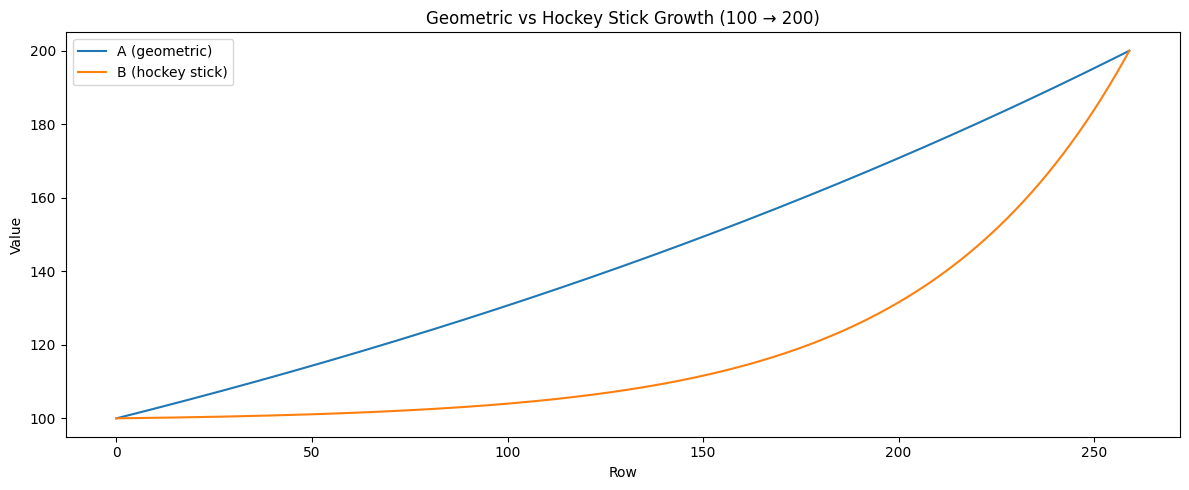

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n = 260

# Column A: geometric growth from 100 to 200 (constant ratio between adjacent elements)
a = np.geomspace(100, 200, n)

# Column B: hockey stick (exponential) growth from 100 to 200
t = np.linspace(0, 1, n)
exp = np.exp(t * 5)
b = 100 + (exp - exp[0]) / (exp[-1] - exp[0]) * 100

df = pd.DataFrame({'A': a, 'B': b})

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['A'], label='A (geometric)')
plt.plot(df.index, df['B'], label='B (hockey stick)')
plt.legend()
plt.title('Geometric vs Hockey Stick Growth (100 → 200)')
plt.xlabel('Row')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


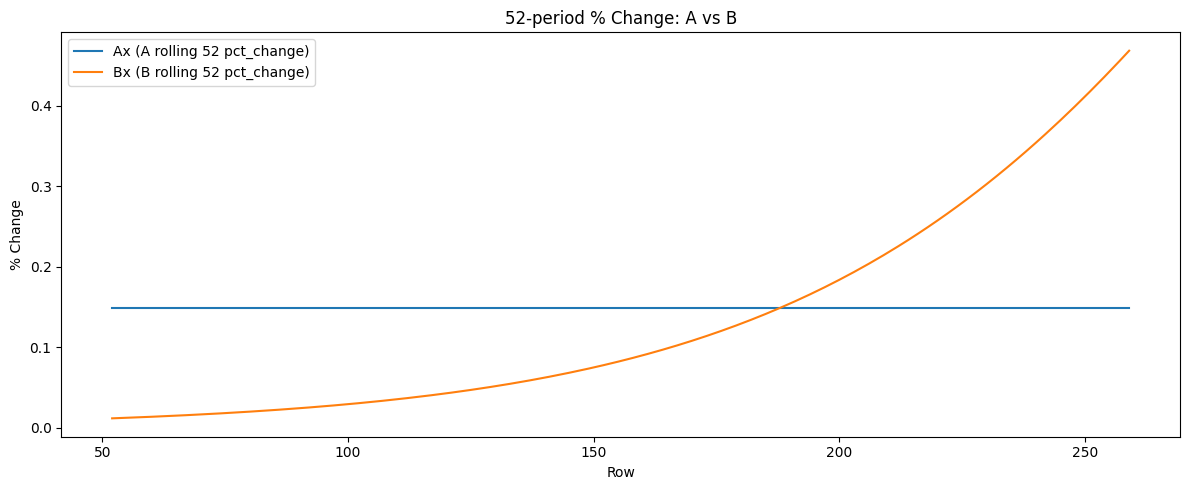

In [5]:
df['Ax'] = df['A'].pct_change(periods=52)
df['Bx'] = df['B'].pct_change(periods=52)

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Ax'], label='Ax (A rolling 52 pct_change)')
plt.plot(df.index, df['Bx'], label='Bx (B rolling 52 pct_change)')
plt.legend()
plt.title('52-period % Change: A vs B')
plt.xlabel('Row')
plt.ylabel('% Change')
plt.tight_layout()
plt.show()


## Stock Performance Score: Geometric Mean of Rolling Annual Returns

### Method

For each week *t*, compute the 1-year (52-week) return:

$$r_t = \frac{P_t - P_{t-52}}{P_{t-52}}$$

Then take the **geometric mean** of all $(1 + r_t)$ values across the full history:

$$\text{Score} = \left(\prod_{t} (1 + r_t)\right)^{1/n} - 1$$

This produces a single annualised percentage that summarises the entire price history into one number, easy to compare across assets.

### Why it penalises volatility

Two assets can have identical start and end prices (same total return) yet score differently. Because the geometric mean is a concave function of returns, uneven return paths score lower than smooth ones — this is **variance drag** (Jensen's inequality applied to compounding).

Concretely: a stock that drifts sideways for years then spikes at the end will have near-zero $r_t$ values early on and very large values late. The geometric mean of that uneven sequence is lower than for a stock that delivered steady annual gains throughout, even if both doubled over the period.

### Interpretation

| Score | Meaning |
|---|---|
| Higher | Consistent year-over-year compounding throughout history |
| Lower | Lumpy or volatile path, even if total return is the same |

This makes the score useful not just as a return metric but as a **quality-of-growth** metric — it rewards assets that compound reliably rather than those that surge late or recover from large drawdowns.


In [6]:
from scipy.stats import gmean

AX_gmean = gmean(1 + df['Ax'].dropna()) - 1
BX_gmean = gmean(1 + df['Bx'].dropna()) - 1

print(f'Geometric mean of Ax: {AX_gmean:.2%}')
print(f'Geometric mean of Bx: {BX_gmean:.2%}')

Geometric mean of Ax: 14.93%
Geometric mean of Bx: 12.76%
